In [45]:
"""
    bibliotekat:
"""
from itertools import combinations
import numpy as np 
from sympy.physics.wigner import clebsch_gordan
from sympy import S
import math
import matplotlib.pyplot as plt
import time

start = time.perf_counter()

In [ ]:
"""
    parametrat globalë:
"""

global N

N = 3 # nr i elektroneve
filling_factor = 3 #5 zgjidhet në varësi të ν = 1/3 apo ν= 1/5 
global Q
Q = 0.5*filling_factor*(N-1)
Lz = int(0)

In [47]:
"""
    gjenerimi i bazës së Fokut
    me Lz të fiksuar
"""

def calc_Lz(state: int) -> int:
    Lz = 0
    m = -Q

    while state:
        if state & 1:
            Lz += m
        state >>= 1
        m += 1

    return Lz


def generate_basis(Lz, N,Nphi = int(2*Q)):
    basis = []
    for occ in combinations(range(Nphi+1), N):
        if sum(occ) - Q*N != Lz:
            continue

        state = 0
        for m in occ:
            state |= (1 << m)

        basis.append(state)
    return basis

basis = generate_basis(Lz, N)
print(len(basis))
def basis_dict(basis):
    bd = {state: i for i, state in enumerate(basis)} #gjendja ne hapesiren e hilbertit e ruajtur si integer -> indeksin
    return bd

2649


In [48]:
"""
    operatorët krijim dhe zhdukje
"""

def count_ones_before(state, i):
    mask = (1 << i) - 1 #zhvendosje e biteve me i
    return bin(state & mask).count('1') #numeron orbitalet e mbushura para se te arrihet numri i qe eshte orbitali i kerkuar
    #operacioni & krijon nje bitstring te ri ku vetem bitet qe jane 1 ne te dy bitstring ruhen dhe aq eshte numri i 1 perpara orbitalit i
#print(count_ones_before(int_basis[2],2))
#print(basis[2])


def create(state, i):
    i = int(i)
    if (state >> i) & 1: #nese gjendja eshte e zene dhe numri 1 jane true, pra 1==1 atehere gjendja shkaterrohet
        return 0, None
    #perndryshe krijon gjendjen
    P = count_ones_before(state, i) #numri i fermioneve para se operatori c†_i te veproje ne orbitalin e i-te
    sign = 1 if P % 2 == 0 else -1 #shenja nga numri i perkembimeve
    new_state = state | (1 << i)
    '''Pjesa me (1 <<i ) i ben flip bitit te i-te pra nga 0 -> 1 dhe vetem bitit te i-te, kurse | pra or nese bitet e tjera jane 0 ose 1 i mban te tille.
       ndryshon vetem biti i i-te.'''
    #print(new_state)
    return sign, new_state


def annihilate(state, i):
    i = int(i)
    if not ((state >> i) & 1): #nese gjendja boshe dhe numri 0 jane true, pra 0==0 atehere gjendja kthehet ne 0
        return 0, None
    #perndryshe ben n_i = 0 gjendjen
    P = count_ones_before(state, i) #numri i fermioneve para se operatori c_i te veproje ne orbitalin e i-te
    sign = 1 if P % 2 == 0 else -1 #shenja nga numri i perkembimeve
    new_state = state & ~ (1 << i)
    '''Pjesa me ~ (1 << i) e detyron bitin e i-te te jete zero, ndersa & pra and i ruan gjithe bitet e tjere te pandryshuar'''
    #print(new_state)
    return sign, new_state

In [49]:
"""
    operatori L^2.
    L^2 = Lz^2 + (L_{+}L_{-} + L_{-}L_{+}) / 2
"""
def pjesaEdyte(basis, basis_dict):
	##############################
	vals = np.arange(-Q,Q+1)
	dim = len(basis)
	pj2 = np.zeros((dim,dim), dtype=float)
	######################################
	for j in range(dim):
		##############
		state=basis[j]
		##############
		"""
			pjesa diagonale:
		"""
		total=0
		for n in vals:
			bit=int(n+Q)
			if (state>>bit)&1:
				total+=Q*(Q+1)-n*(n+1)
		
		pj2[j,j]+=total
		##############
		"""
			ish-operatoriPlusMinus
		"""
		for m in vals[:-1]:
			for n in vals[1:]:
				a_m=np.sqrt( Q*(Q+1) - m*(m+1) )
				a_nMinus1=np.sqrt( Q*(Q+1) - (n-1)*((n-1)+1) )
				mBit = int(m+Q)
				nBit = int(n+Q)
				######################################
				sgn1, state_ = annihilate(state, nBit)
				if state_==None:
					continue
				sgn2, state_ = annihilate(state_, mBit)
				if state_==None:
					continue
				sgn3, state_ = create(state_, nBit-1)
				if state_==None:
					continue
				sgn4, state_ = create(state_, mBit+1)
				if state_==None:
					continue
				##########################
				i = basis_dict.get(state_)
				pj2[i,j] -= sgn1*sgn2*sgn3*sgn4 * a_nMinus1 * a_m
				################################################
	return pj2


pj2 = pjesaEdyte(basis, basis_dict(basis))
L2 = np.eye(len(basis)) * (Lz**2) + pj2
l, psi = np.linalg.eigh(L2)

In [50]:
"""
    numërimi i gjendjeve me anën e multipleteve:
"""
def get_L(l):
    l = np.asarray(l)
    # kthe rrënjën positive të ekuacionit l=L(L+1)
    L = (-1 + np.sqrt(1 + 4*l)) / 2
    # rezultati duhet të jetë numër i plotë
    return np.rint(L).astype(int)
    return L

# për kontroll, nëse nuk del i plotë:
def get_L_nonInt(l):
    l = np.asarray(l)
    # kthe rrënjën positive të ekuacionit l=L(L+1)
    L = (-1 + np.sqrt(1 + 4*l)) / 2
    # rezultati duhet të jetë numër i plotë
    return L

##########################################
# për çdo multiplet L, kemi 2L+1 gjendje:
Ls = get_L(l)
Ls_ = get_L_nonInt(l)
n_states = 0
for L in Ls:
    n_states += (2*L+1)

print("Numri i multipleteve është "+str(len(basis))+", ndërsa i gjendjeve është "+str(n_states)+".")

Numri i multipleteve është 2649, ndërsa i gjendjeve është 118755.


In [51]:
print( np.max(np.abs(Ls-Ls_)) )

6.690203946391193e-13


In [52]:
"""
    elementët matricorë të projektorit 
    në nënhapësirën dygrimcore me moment kinetik relativ m
"""
def matricaDyGrimcore_P( m ):
    J = int(2*Q-m)
    PJ = np.zeros((int((2*Q+1)**2), int((2*Q+1)**2)), dtype=float)
    ##############################################################
    # m1, m2, n1, n2 janë numra në -Q,...,+Q
    # m1_, m2_, n1_, n2_ janë numra në 0,...,+2Q
    for m1_ in range(int(2*Q+1)):
        m1 = m1_ - Q
        for m2_ in range(int(2*Q+1)):
            m2 = m2_ - Q
            # linearizim i indeksimit (m1,m2)
            indeksi_m = m1_ * int(2*Q+1) + m2_
            for n1_ in range(int(2*Q+1)):
                n1 = n1_ - Q
                for n2_ in range(int(2*Q+1)):
                    n2 = n2_ - Q
                    # linearizim i indeksimit (m1,m2)
                    indeksi_n = n1_ * int(2*Q+1) + n2_
                    ###################################
                    ###################################
                    ####### M merr vlera në -J,...,+J
                    # for M in np.arange(-J,J+1):
                    #     cg1 = np.float64(clebsch_gordan(S(Q), S(Q), S(J), S(m1), S(m2), S(M)))
                    #     cg2 = np.float64(clebsch_gordan(S(Q), S(Q), S(J), S(n1), S(n2), S(M)))
                    #     PJ[indeksi_m, indeksi_n] += cg1*cg2
                    M = m1 + m2
                    if n1 + n2 != M:
                        continue
                    cg1 = np.float64(clebsch_gordan(S(Q), S(Q), S(J), S(m1), S(m2), S(M)))
                    cg2 = np.float64(clebsch_gordan(S(Q), S(Q), S(J), S(n1), S(n2), S(M)))
                    PJ[indeksi_m, indeksi_n] += cg1 * cg2
    ######################################################
    return PJ

In [53]:
"""
    funksioni që kthen listën e pseudopotencialeve 
    të HALDANE-it për bashkëveprimin Kulonian
"""
def coulomb_pps():
    twoQ = int(round(2*Q))
    vjs = np.zeros(twoQ + 1, dtype=float)
    for J in range(twoQ + 1):
        a = 2*twoQ - 2*J
        b = twoQ - J
        c = 2*twoQ + 2*J + 2
        d = twoQ + J + 1
        e = 2*twoQ + 2
        f = twoQ + 1
        vjs[J] = (
            2
            * math.comb(a, b)
            * math.comb(c, d)
            * (math.comb(e, f)**(-2))
            / np.sqrt(Q)
        )
    # në fakt, m=2Q-J
    return np.flip(vjs)

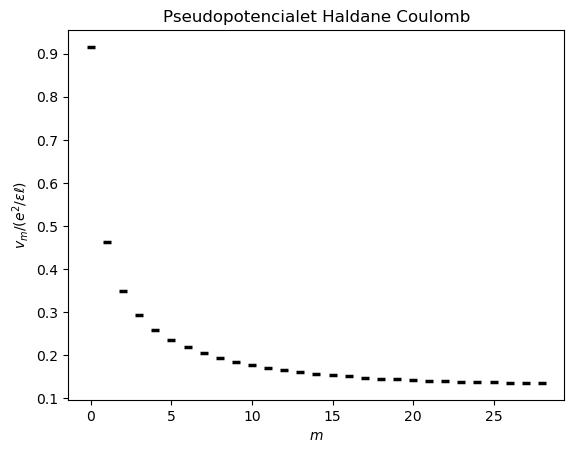

In [ ]:
vms = coulomb_pps();
plt.title("Pseudopotencialet Haldane Coulomb");
plt.plot(vms, marker = "_", color = "black", linestyle = "",markeredgewidth=2.5);
plt.xlabel("$m$");
plt.ylabel("$v_m / (e^2 / \\epsilon \\ell)$");

In [55]:
"""
    matrica dygrimcore e Hamiltonianit
    si funksion i listës së pseudopotencialeve të Haldane-it.
    Lista e pp nis nga m=0,... deri në m=2Q.
    Për modelin V1, kemi V_1 = 1, të tjerët zero.
    Lista jepet e gjatë deri te pseudopotenciali i fundit jo zero,
    p.sh, për modelin V1: 
    vms = [0.0, 1.0] 
"""
def V_matrix( vms ):
    V = np.zeros((int((2*Q+1)**2), int((2*Q+1)**2)), dtype=float)
    for m in range(len(vms)):
        if vms[m]==0.0:
            continue
        V += vms[m] * matricaDyGrimcore_P(m)
    return V

In [ ]:
"""
    Vlerat vetjake të matricës V1234
    duhet të dalin pseudopotencialet v_m,
    secili i degjeneruar 2*J+1 herë, 
    ku J = 2Q-m
"""
vms = coulomb_pps()
V1234 = V_matrix(vms)
evals = np.linalg.eigvalsh(V1234)
#################################
for m, vm in enumerate(vms):
    J = int(2*Q - m)
    deg_expected = 2*J + 1
    deg_found = np.sum(np.isclose(evals, vm, atol=1e-10))
    print(m, vm, deg_expected, deg_found)

'vms = coulomb_pps()\nV1234 = V_matrix(vms)\nevals = np.linalg.eigvalsh(V1234)\n#################################\nfor m, vm in enumerate(vms):\n    J = int(2*Q - m)\n    deg_expected = 2*J + 1\n    deg_found = np.sum(np.isclose(evals, vm, atol=1e-10))\n    print(m, vm, deg_expected, deg_found)'

In [ ]:
"""
    zgjedhja e bashkëveprimit.
    Kulomb, ose Laughlin
"""
# Për Laughlin
# Modeli i bashkëveprimit për ν = 1/3: v0=0, v1=1, të tjerat zero: vms = [0.0, 1.0]
# Modeli i bashkëveprimit për ν = 1/5: vms = [0.0,1.0,0.0,1.0]
# Modeli i bashkëveprimit për ν = 1/7: vms = [0.0,1.0,0.0,1.0,0.0,1.0]
vms_L = [0.0,1.0,0.0,1.0,0.0,1.0]
#COULOMB:
vms_C = coulomb_pps();
#############################
#############################
# pak e kushtueshme në kohë...
#V1234_C = V_matrix(vms_C);
#V1234_L = V_matrix(vms_L);

In [58]:
def operatori_i_hamiltonianit(state, m1, m2, n1, n2):
    # c_{n1}
    sign1, state_ = annihilate(state, n1)
    if state_ == None:
        return 0, None
    ###################
    # c_{n2}
    sign2, state_ = annihilate(state_, n2)
    if state_ == None:
        return 0, None
    ###################
    # c†_{m2}
    sign3, state_ = create(state_, m2)
    if state_ == None:
        return 0, None
    ###################
    # c†_{m1}
    sign4, state_ = create(state_, m1)
    if state_ == None:
        return 0, None
    ###################
    # Shenja totale
    sign = sign1 * sign2 * sign3 * sign4
    #####################################
    return sign, state_

In [59]:
def Hamiltoniani(basis, basis_dict, V1234):
    dim = len(basis)
    H = np.zeros((dim, dim), dtype=complex)
    ###########################################
    ###########################################
    # Kalo nëpër çdo element të bazës së Fokut:
    for j in range(dim):
        ################
        state = basis[j]
        #########################################
        # m1, m2, n1, n2 janë numra në -Q,...,+Q
        # m1_, m2_, n1_, n2_ janë numra në 0,...,+2Q
        for m1_ in range(int(2*Q+1)):
            m1 = m1_ - Q
            for m2_ in range(int(2*Q+1)):
                m2 = m2_ - Q
                # linearizim i indeksimit (m1,m2)
                indeksi_m = m1_ * int(2*Q+1) + m2_
                for n1_ in range(int(2*Q+1)):
                    n1 = n1_ - Q
                    #################
                    n2 = m1 + m2 - n1
                    if abs(n2)>Q:
                        continue
                    n2_ = int(n2 + Q)
                    # linearizim i indeksimit (m1,m2)
                    indeksi_n = n1_ * int(2*Q+1) + n2_
                    ##################################
                    val = V1234[indeksi_m, indeksi_n]
                    if val==0:
                        continue
                    #####################################################################
                    # sgn, new_state = operatori_i_hamiltonianit(state, m1_, m2_, n2_, n1_)
                    sgn, new_state = operatori_i_hamiltonianit(state, m1_, m2_, n1_, n2_)
                    if new_state is None:
                        continue
                    i = basis_dict.get(new_state)
                    ###################
                    H[i, j] += 0.5 * val*sgn
    return H

In [ ]:
#Ruan matricën e Hamiltonianit

import os

os.makedirs("data/Hamiltoniani_m5", exist_ok=True)

V1234 = V_matrix(vms_C)
H = Hamiltoniani(basis, basis_dict(basis), V1234)
np.save("data/Hamiltoniani_m5/H"+str(N)+"coulomb.npy", H)
del V1234
del H

V1234 = V_matrix(vms_L)

H = Hamiltoniani(basis, basis_dict(basis), V1234)
np.save("data/Hamiltoniani_m5/H"+str(N)+"Laughlin.npy", H)
del V1234
del H

'import os\n\nos.makedirs("data/Hamiltoniani_m7", exist_ok=True)\n\nV1234 = V_matrix(vms_C)\nH = Hamiltoniani(basis, basis_dict(basis), V1234)\nnp.save("data/Hamiltoniani_m7/H"+str(N)+"coulomb.npy", H)\ndel V1234\ndel H\n\nV1234 = V_matrix(vms_L)\n\nH = Hamiltoniani(basis, basis_dict(basis), V1234)\nnp.save("data/Hamiltoniani_m7/H"+str(N)+"Laughlin.npy", H)\ndel V1234\ndel H'

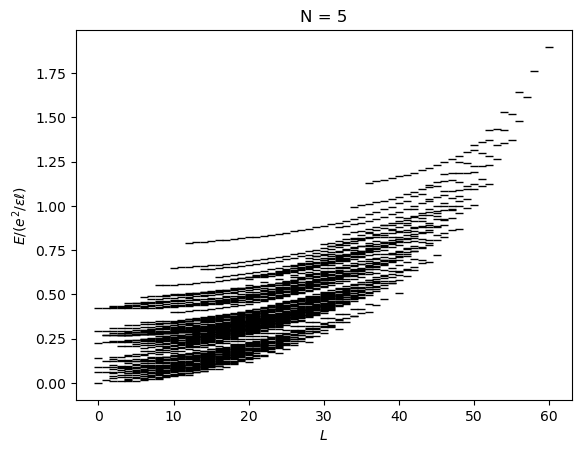

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

H_C = np.load("data/Hamiltoniani_m5/H"+str(N)+"coulomb.npy")
H_L = np.load("data/Hamiltoniani_m5/H"+str(N)+"Laughlin.npy")


E_C, Psi_C = np.linalg.eigh(H_C)
E_L, Psi_L = np.linalg.eigh(H_L)

plt.clf();
for i in range(len(basis)):
    # energjitë i masim relativisht me gjendjen bazë, 
    # për bashkëveprimin Kulonian.
    # Për v1, gjendja bazë del zero vetëvetiu:
    e = E_C[i] - E_C[0]
    psi = Psi_C[:,i]
    expval_L2 = np.real(np.vdot(psi, L2 @ psi))
    L = get_L_nonInt(expval_L2)
    plt.plot(
        L,
        e,
        marker="_",
        color="black",
        linestyle=""
    )
plt.title(f"N = {N}")
plt.xlabel("$L$")
plt.ylabel("$E / (e^2 / \\epsilon \\ell)$")

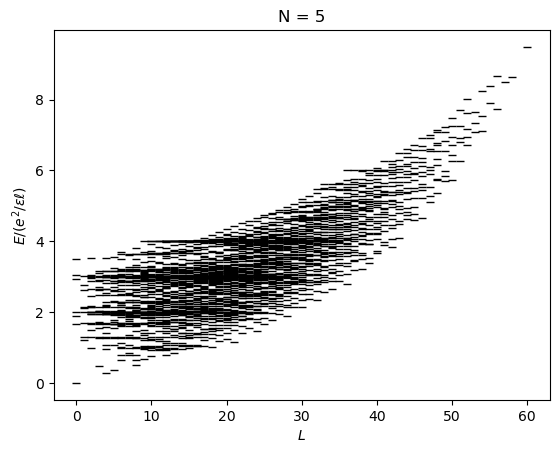

In [ ]:
plt.clf();
for i in range(len(basis)):
    # energjitë i masim relativisht me gjendjen bazë, 
    # për bashkëveprimin Kulomian.
    # Për v1, gjendja bazë del zero vetëvetiu:
    e = E_L[i] - E_L[0]
    psi = Psi_L[:,i]
    expval_L2 = np.real(np.vdot(psi, L2 @ psi))
    L = get_L_nonInt(expval_L2)
    plt.plot(
        L,
        e,
        marker="_",
        color="black",
        linestyle=""
    )
plt.title(f"N = {N}")
plt.xlabel("$L$")
plt.ylabel("$E / (e^2 / \\epsilon \\ell)$")

In [ ]:
from IPython.display import display, Math
import os
#projeksioni i funksioni valor Laughlin mbi atë nga bashkëveprimi Kulonian ⟨ψ_L|ψ_C⟩

psi_C = Psi_C[:,0]
psi_L = Psi_L[:,0]

psi_C = psi_C / np.linalg.norm(psi_C)
psi_L = psi_L / np.linalg.norm(psi_L)


proj = np.abs(np.vdot(psi_C, psi_L))

display(Math(
    rf"N={N},\quad \langle \psi_C | \psi_L \rangle = {proj:.8f}"
))

<IPython.core.display.Math object>

In [ ]:
#Llogaritja e ⟨ψ_C| Ĥ_L |ψ_C⟩ = E₁
#Llogaritja e ⟨ψ_L| Ĥ_C |ψ_L⟩ = E₂

E1 = np.real(np.vdot(psi_C, H_L @ psi_C))
E2 = np.real(np.vdot(psi_L, H_C @ psi_L))

print(f"E1 = {E1:.8f}")
print(f"E2 = {E2:.8f}")
dE = abs(E1 - E2)
print(f"|E1 - E2| = {abs(E1 - E2):.8f}")

E1 = 0.01816102
E2 = 1.78022957
|E1 - E2| = 1.76206856


In [ ]:
#Diferenca E⁰_C - E⁰_L

dE0 = np.abs(E_C[0] - E_L[0])

print(f"{dE0:.8f}")

1.77986324


In [66]:
end = time.perf_counter()

print(end-start)

131.13085933799994
